In [2]:
# load modules to make mplhep plots and read a root file
import matplotlib.pyplot as plt
import mplhep as hep
import uproot
import numpy as np
import awkward as ak

In [3]:
# now load the root file
file = uproot.open("TestData/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_testFile.root")
# check the tree name
file.keys()
tree = file["Events"]

In [4]:
# check what;s the content
print(tree.keys())

['target_res_mass_factor', 'output_target_res_mass_factor', 'target_parts_mass_factor', 'output_target_parts_mass_factor', 'output_target_res_mass_factor_label_H_bb', 'output_target_res_mass_factor_label_H_cc', 'output_target_res_mass_factor_label_H_ss', 'output_target_res_mass_factor_label_H_qq', 'output_target_res_mass_factor_label_Hp_bc', 'output_target_res_mass_factor_label_Hm_bc', 'output_target_res_mass_factor_label_H_bs', 'output_target_res_mass_factor_label_Hp_cs', 'output_target_res_mass_factor_label_Hm_cs', 'output_target_res_mass_factor_label_H_gg', 'output_target_res_mass_factor_label_H_ee', 'output_target_res_mass_factor_label_H_mm', 'output_target_res_mass_factor_label_H_tauhtaue', 'output_target_res_mass_factor_label_H_tauhtaum', 'output_target_res_mass_factor_label_H_tauhtauh', 'output_target_res_mass_factor_label_QCD_bb', 'output_target_res_mass_factor_label_QCD_cc', 'output_target_res_mass_factor_label_QCD_b', 'output_target_res_mass_factor_label_QCD_c', 'output_targe

In [5]:
# now make 2D plots of the following variables:
# target_res_mass_factor vs scoutfj_glopart_massreg
# score_label_H_bb vs scoutfj_glopart_probHbb
# score_label_H_cc vs scoutfj_glopart_probHcc
# score_label_H_qq vs scoutfj_glopart_probHqq


# get the arrays
mass_factor = tree["output_target_res_mass_factor"].array()
glopart_massreg = tree["scoutfj_glopart_massreg"].array()
score_label_H_bb = tree["score_label_H_bb"].array()
glopart_probHbb = tree["scoutfj_glopart_probHbb"].array()
score_label_H_cc = tree["score_label_H_cc"].array()
glopart_probHcc = tree["scoutfj_glopart_probHcc"].array()
score_label_H_qq = tree["score_label_H_qq"].array()
glopart_probHqq = tree["scoutfj_glopart_probHqq"].array()

print (mass_factor, len(mass_factor))
print (glopart_massreg, len(glopart_massreg))

[0.678, 0.456, 0.345, 0.255, 0.6, 0.0722, ..., 0.364, 0.425, 0.34, 0.35, 0.642] 1024
[0.677, 0.456, 0.345, 0.255, 0.6, 0.0723, ..., 0.364, 0.424, 0.34, 0.35, 0.641] 1024


1024 1024


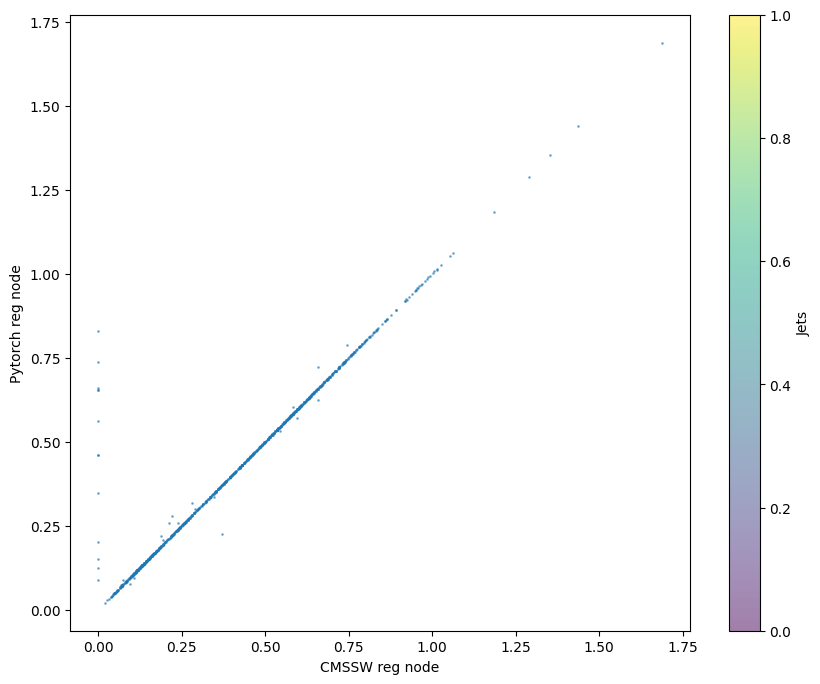

<Figure size 640x480 with 0 Axes>

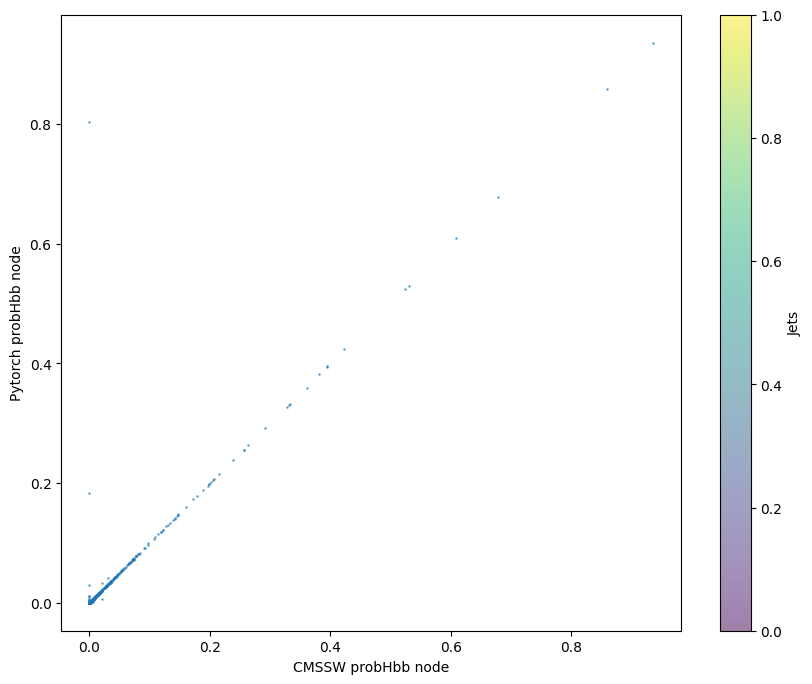

<Figure size 640x480 with 0 Axes>

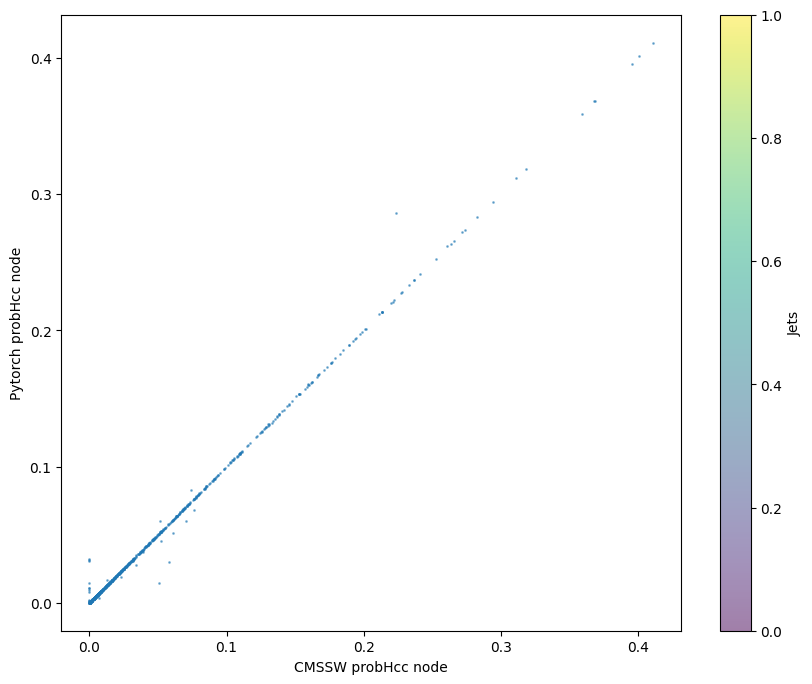

<Figure size 640x480 with 0 Axes>

In [11]:
print (len(score_label_H_bb), len(glopart_probHbb))

# make the 2d histograms
plt.figure(figsize=(10,8))
plt.scatter(np.array(glopart_massreg), np.array(mass_factor), s=1, alpha=0.5)
plt.xlabel("CMSSW reg node")
plt.ylabel("Pytorch reg node")
plt.colorbar(label='Jets')
# plt.title("2D Histogram of scoutfj_glopart_massreg vs target_res_mass_factor")
plt.show()
plt.clf()


# now the same for the other variables
plt.figure(figsize=(10,8))
plt.scatter(np.array(glopart_probHbb), np.array(score_label_H_bb), s=1, alpha=0.5)
plt.xlabel("CMSSW probHbb node")
plt.ylabel("Pytorch probHbb node")
plt.colorbar(label='Jets')
# plt.title("2D Histogram of CMSSW probHbb node vs Pytorch probHbb node")
plt.show()
plt.clf()

plt.figure(figsize=(10,8))
plt.scatter(np.array(glopart_probHqq), np.array(score_label_H_qq), s=1, alpha=0.5)
plt.xlabel("CMSSW probHcc node")
plt.ylabel("Pytorch probHcc node")
plt.colorbar(label='Jets')
# plt.title("2D Histogram of CMSSW probHcc node vs Pytorch probHcc node")
plt.show()
plt.clf()

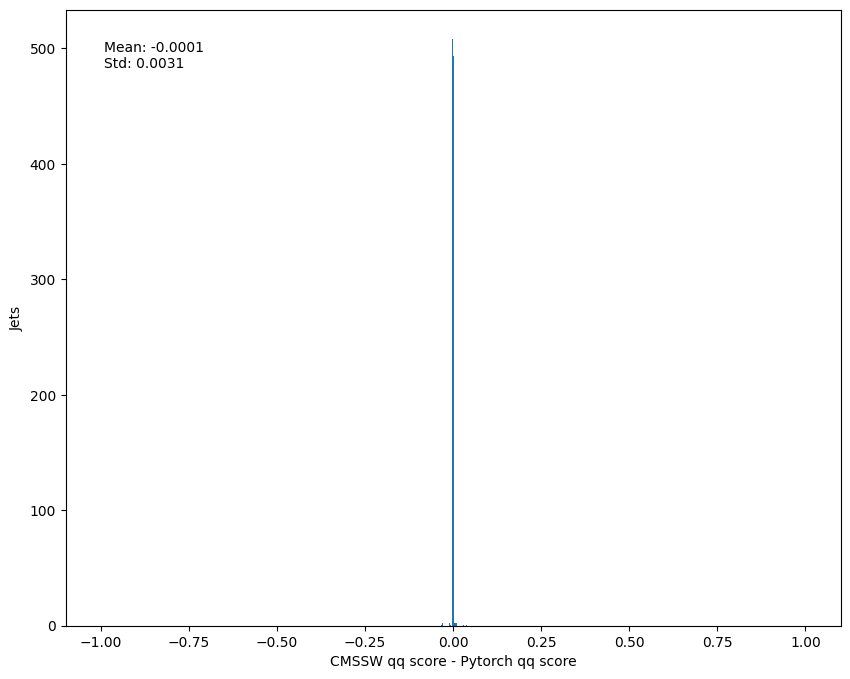

<Figure size 640x480 with 0 Axes>

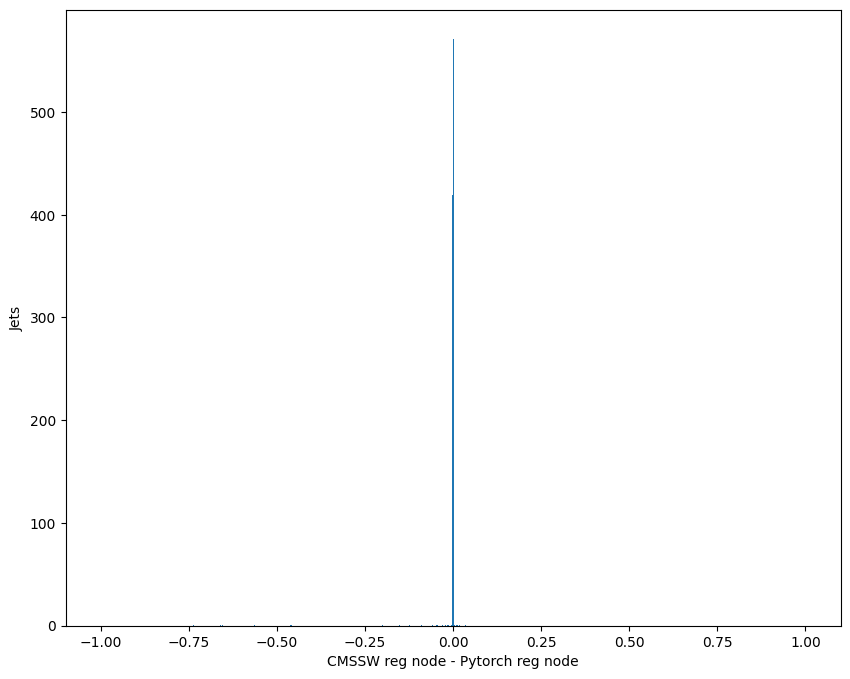

<Figure size 640x480 with 0 Axes>

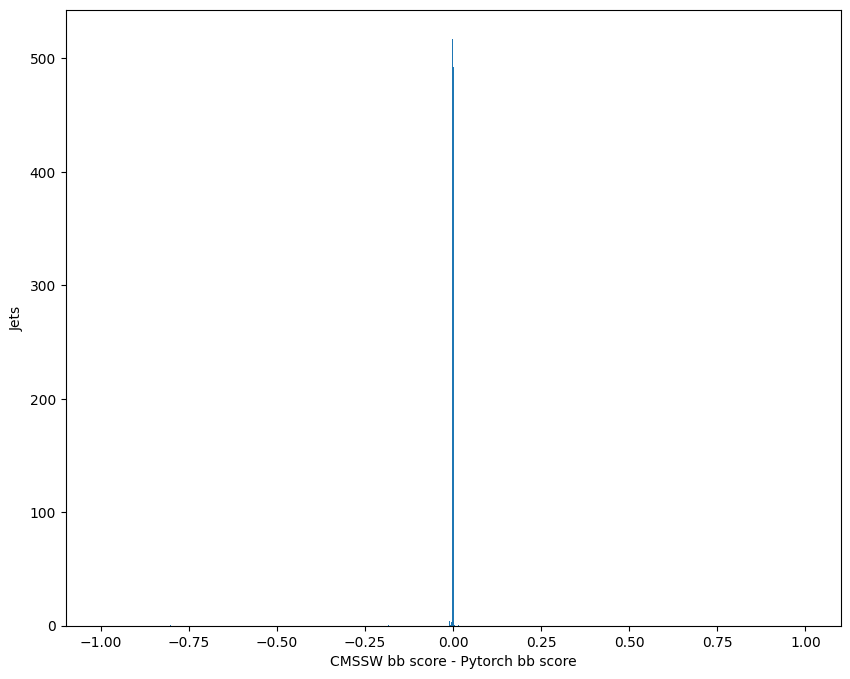

<Figure size 640x480 with 0 Axes>

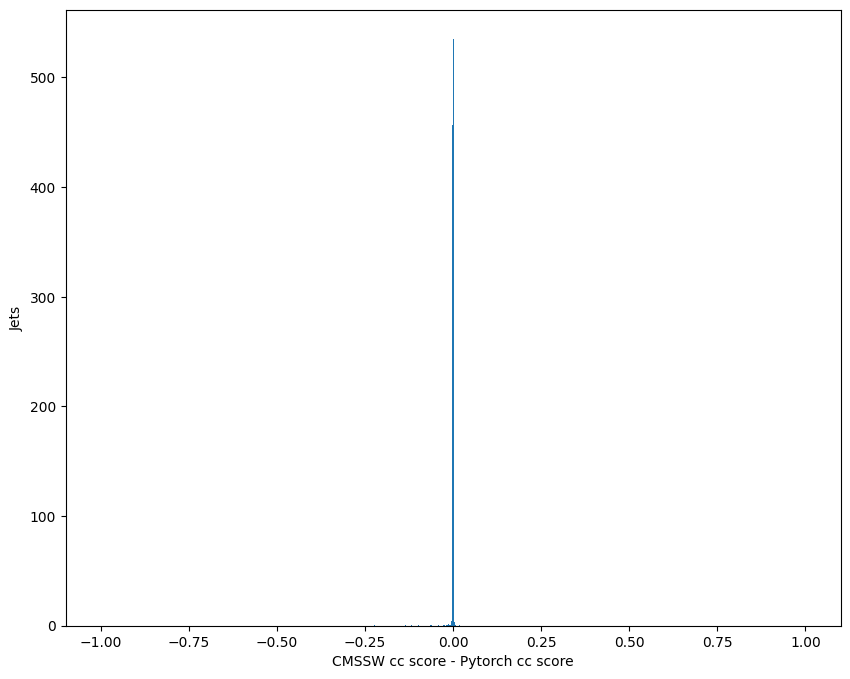

<Figure size 640x480 with 0 Axes>

In [ ]:
# now plot the differences as 1d
plt.figure(figsize=(10,8))
plt.hist(np.array(glopart_probHqq) - np.array(score_label_H_qq), bins=1000, range=(-1, 1))
plt.xlabel("CMSSW qq score - Pytorch qq score")
# add text with mean and std
mean_diff = np.mean(np.array(glopart_probHqq) - np.array(score_label_H_qq))
std_diff = np.std(np.array(glopart_probHqq) - np.array(score_label_H_qq))
plt.text(0.05, 0.95, f"Mean: {mean_diff:.4f}\nStd: {std_diff:.4f}", transform=plt.gca().transAxes, verticalalignment='top')
plt.ylabel("Jets")
# plt.title("Histogram of scoutfj_glopart_probHqq - score_label_H_qq")
plt.show()
plt.clf()

plt.figure(figsize=(10,8))
plt.hist(np.array(glopart_massreg) - np.array(mass_factor), bins=1000, range=(-1, 1))
plt.xlabel("CMSSW reg node - Pytorch reg node")
# add text with mean and std
mean_diff = np.mean(np.array(glopart_massreg) - np.array(mass_factor))
std_diff = np.std(np.array(glopart_massreg) - np.array(mass_factor))
plt.text(0.05, 0.95, f"Mean: {mean_diff:.4f}\nStd: {std_diff:.4f}", transform=plt.gca().transAxes, verticalalignment='top')
plt.ylabel("Jets")
# plt.title("Histogram of scoutfj_glopart_massreg - target_res_mass_factor")
plt.show()
plt.clf()

# and bb and cc
plt.figure(figsize=(10,8))
plt.hist(np.array(glopart_probHbb) - np.array(score_label_H_bb), bins=1000, range=(-1, 1))
plt.xlabel("CMSSW bb score - Pytorch bb score")
# add text with mean and std
mean_diff = np.mean(np.array(glopart_probHbb) - np.array(score_label_H_bb))
std_diff = np.std(np.array(glopart_probHbb) - np.array(score_label_H_bb))
plt.text(0.05, 0.95, f"Mean: {mean_diff:.4f}\nStd: {std_diff:.4f}", transform=plt.gca().transAxes, verticalalignment='top')
plt.ylabel("Jets")
# plt.title("Histogram of scoutfj_glopart_probHbb - score_label_H_bb")
plt.show()
plt.clf()

plt.figure(figsize=(10,8))
plt.hist(np.array(glopart_probHcc) - np.array(score_label_H_cc), bins=1000, range=(-1, 1))
plt.xlabel("CMSSW cc score - Pytorch cc score")
# add text with mean and std
mean_diff = np.mean(np.array(glopart_probHcc) - np.array(score_label_H_cc))
std_diff = np.std(np.array(glopart_probHcc) - np.array(score_label_H_cc))
plt.text(0.05, 0.95, f"Mean: {mean_diff:.4f}\nStd: {std_diff:.4f}", transform=plt.gca().transAxes, verticalalignment='top')
plt.ylabel("Jets")
# plt.title("Histogram of scoutfj_glopart_probHcc - score_label_H_cc")
plt.show()
plt.clf()